# Evaluating latent factors and firing rates inferred by `lfads-torch`

In [148]:
import re
from glob import glob
import numpy as np
from scipy.io import loadmat
from scipy.signal import lfilter
from scipy.signal.windows import gaussian
import h5py
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Load LFADS factors and rates from output files

In [149]:
LFADS_OUTPUT_PATHS = sorted(glob("lfads_output_v1_10_*.h5"))
LFADS_OUTPUT_PATHS

['lfads_output_v1_10_v1.h5']

In [150]:
stimulus_id_list = np.loadtxt('v1_stimulus_id')

In [151]:
stimulus_id_list.shape

(3025,)

In [152]:
# use train_inds and valid_inds to put data back to original order

def merge_data(train_data, valid_data, train_inds, valid_inds):
    n_neurons = train_data.shape[2]
    n_timepoints = train_data.shape[1]
    n_trials = train_data.shape[0] + valid_data.shape[0]
    merged_data = np.zeros((n_trials, n_timepoints, n_neurons))
    for i, ind in enumerate(train_inds):
        merged_data[ind] = train_data[i]
    for i, ind in enumerate(valid_inds):
        merged_data[ind] = valid_data[i]
    return merged_data

In [153]:
rates = {}
factors = {}
spikes = {}
inferred_inputs = {}
initial_conditions = {}
bin_width_sec = 0.01

for data_path in LFADS_OUTPUT_PATHS:
    session_id = data_path.rsplit('_', 1)[-1].split('.')[0]
    print(session_id)
    
    with h5py.File(data_path, 'r') as f:
        print(list(f.keys()))
        train_encod_data = f['train_encod_data'][:]
        valid_encod_data = f['valid_encod_data'][:]
        train_factors = f['train_factors'][:]
        valid_factors = f['valid_factors'][:]
        train_rates = f["train_output_params"][:]
        valid_rates = f["valid_output_params"][:]
        train_inferred_inputs = f['train_co_means'][:]
        valid_inferred_inputs = f['valid_co_means'][:]
        train_initial_conditions = f['train_ic_mean'][:]
        valid_initial_conditions = f['valid_ic_mean'][:]
        train_inds = f['train_inds'][:].astype(int)
        valid_inds = f['valid_inds'][:].astype(int)

        spikes[session_id] = merge_data(train_encod_data, valid_encod_data, train_inds, valid_inds)
        factors[session_id] = merge_data(train_factors, valid_factors, train_inds, valid_inds)
        rates[session_id] = merge_data(train_rates, valid_rates, train_inds, valid_inds)
        inferred_inputs[session_id] = merge_data(train_inferred_inputs, valid_inferred_inputs, train_inds, valid_inds)
        initial_conditions[session_id] = np.concatenate((train_initial_conditions, valid_initial_conditions), axis=0)


v1
['train_co_means', 'train_co_stds', 'train_con_states', 'train_encod_data', 'train_factors', 'train_gen_init', 'train_gen_inputs', 'train_gen_states', 'train_ic_mean', 'train_ic_std', 'train_inds', 'train_output_params', 'train_recon_data', 'valid_co_means', 'valid_co_stds', 'valid_con_states', 'valid_encod_data', 'valid_factors', 'valid_gen_init', 'valid_gen_inputs', 'valid_gen_states', 'valid_ic_mean', 'valid_ic_std', 'valid_inds', 'valid_output_params', 'valid_recon_data']


In [154]:
spikes['v1'].shape

(3025, 50, 884)

In [155]:
def mean_by_stimulus_id(data, stimulus_ids):
    stimulus_ids = np.array(stimulus_ids)
    unique_ids = np.unique(stimulus_ids)
    
    n_unique = len(unique_ids)
    if len(data.shape) == 2:
        mean_matrix = np.zeros((n_unique, data.shape[1]))
    else:
        mean_matrix = np.zeros((n_unique, data.shape[1], data.shape[2]))
    counts = np.zeros(n_unique, dtype=int)  # Array to store how many rows per ID
    
    for i, s_id in enumerate(unique_ids):
        mask = (stimulus_ids == s_id)
        counts[i] = np.sum(mask)  # Count the True values in the mask
        
        # Calculate mean
        mean_matrix[i] = np.mean(data[mask], axis=0)
    
    # Validation Check
    total_rows_processed = np.sum(counts)
    print(f"Total rows in input: {data.shape[0]}")
    print(f"Total rows accounted for: {total_rows_processed}")
    
    if total_rows_processed == data.shape[0]:
        print("Success: All rows were used.")
    else:
        print("Some rows were missed or double-counted.")
        
    return unique_ids, mean_matrix, counts

In [156]:
stimulus_id_map = {}
map_list = np.loadtxt('stimulus_id_map.txt')
for i in range(len(map_list)):
    stimulus_id_map[i] = map_list[i]

In [157]:
stimulus_id_map

{0: array([45.,  0., 30.]),
 1: array([  0., -30., -10.]),
 2: array([45., 10., 20.]),
 3: array([  0., -40., -40.]),
 4: array([ 90., -10., -10.]),
 5: array([ 90., -30., -20.]),
 6: array([  0.,   0., -10.]),
 7: array([  0.,  40., -20.]),
 8: array([ 90.,   0., -20.]),
 9: array([45., 30., 20.]),
 10: array([ 90., -10., -40.]),
 11: array([0., 0., 0.]),
 12: array([  0., -30., -20.]),
 13: array([  0.,  20., -10.]),
 14: array([  0., -20., -20.]),
 15: array([ 90., -40., -40.]),
 16: array([ 90., -40., -20.]),
 17: array([ 90.,   0., -10.]),
 18: array([  0.,  20., -30.]),
 19: array([ 90., -10.,   0.]),
 20: array([  0., -30., -30.]),
 21: array([ 45., -40., -10.]),
 22: array([ 90., -10., -30.]),
 23: array([ 90., -20., -20.]),
 24: array([45., 30., 30.]),
 25: array([ 45.,   0., -10.]),
 26: array([ 45.,  10., -10.]),
 27: array([  0., -30.,  30.]),
 28: array([  0., -20.,  20.]),
 29: array([ 45., -40.,  30.]),
 30: array([ 0., 40., 20.]),
 31: array([  0., -20.,  40.]),
 32: ar

In [158]:
len(inferred_inputs['v1'][:, :, 0].shape)

2

In [159]:
_, mean_spikes, _ = mean_by_stimulus_id(spikes['v1'], stimulus_id_list)
_, mean_rates, _ = mean_by_stimulus_id(rates['v1'], stimulus_id_list)
_ , mean_factors, _ = mean_by_stimulus_id(factors['v1'], stimulus_id_list)
_ , mean_inputs, _ = mean_by_stimulus_id(inferred_inputs['v1'], stimulus_id_list)

Total rows in input: 3025
Total rows accounted for: 3025
Success: All rows were used.
Total rows in input: 3025
Total rows accounted for: 3025
Success: All rows were used.
Total rows in input: 3025
Total rows accounted for: 3025
Success: All rows were used.
Total rows in input: 3025
Total rows accounted for: 3025
Success: All rows were used.


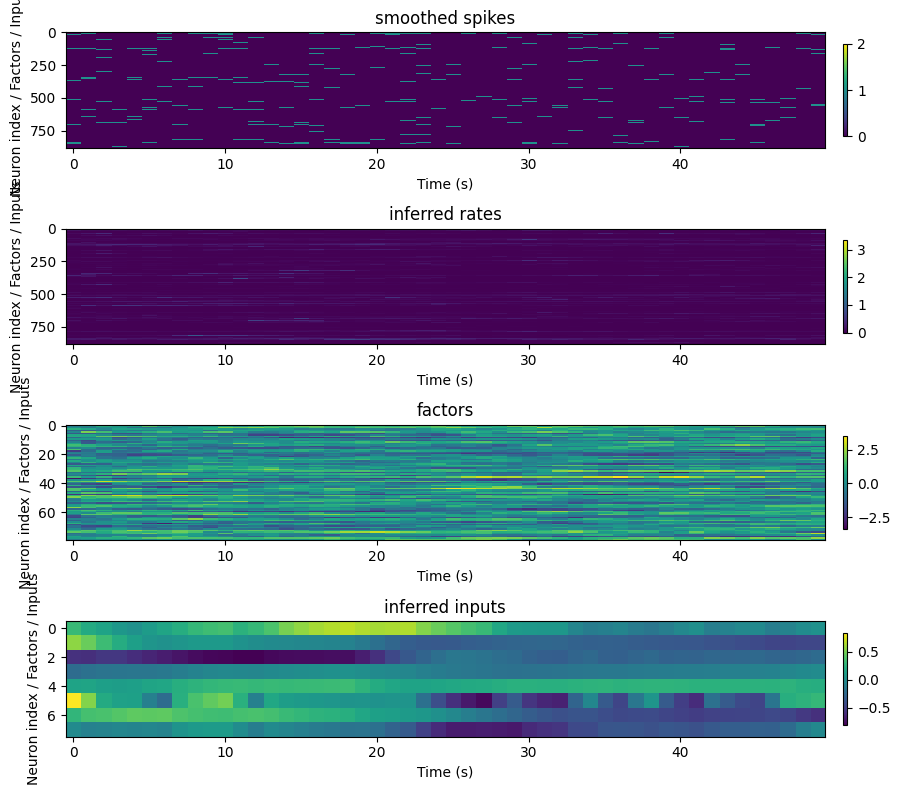

In [160]:
import matplotlib.pyplot as plt

# Visualize raw spikes, smoothed spikes, LFADS rates, and LFADS factors for a single trial
session = "v1"
trial = 3
data = {
    "smoothed spikes": spikes[session][trial],
    "inferred rates": rates[session][trial],
    "factors": factors[session][trial],
    "inferred inputs": inferred_inputs[session][trial]
}

fig, axes = plt.subplots(nrows=4, figsize=(10, 8))
for ax, (name, data_val) in zip(axes, data.items()):
    im = ax.imshow(data_val.T, aspect='auto', interpolation='none', cmap='viridis')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Neuron index / Factors / Inputs')
    ax.set_title(name)
    ax.grid(False)
    fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
plt.tight_layout()

As an additional check, we can plot the PSTHs of the LFADS rates to verify if they are comparable to the empirical PSTHs obtained using smoothed spikes.
For simplicity, we do this for a single session and 20 neurons below.

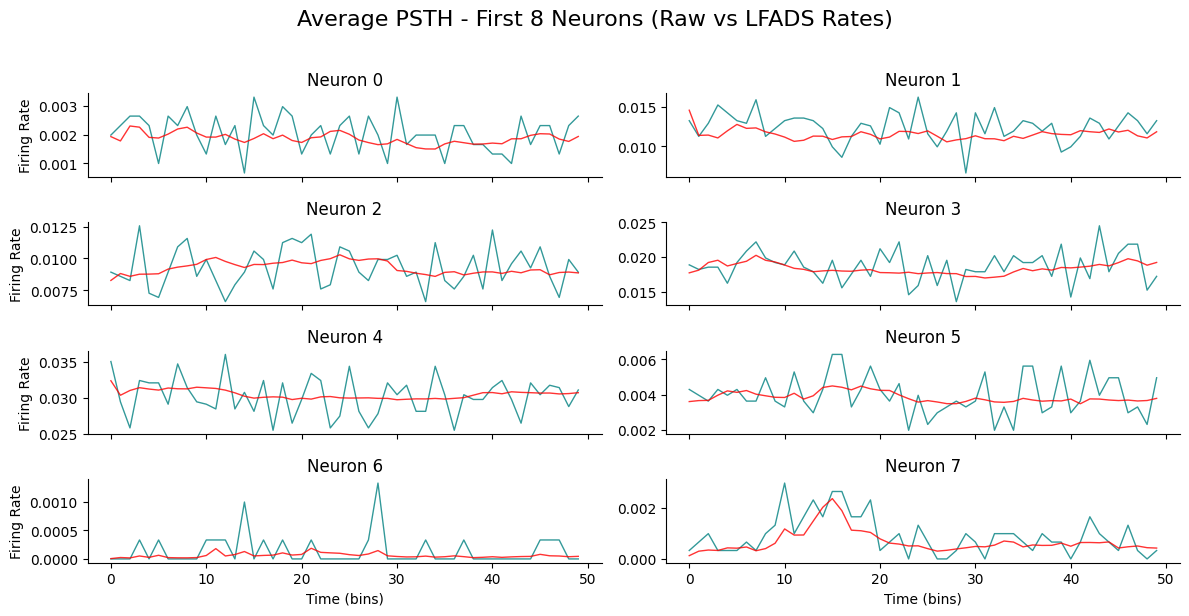

In [161]:
def plot_overlay_psths_first_8(spikes_data, rates_data, title):
    # Create a 4x2 grid to fit exactly 8 neurons
    fig, axes = plt.subplots(4, 2, figsize=(12, 6), sharex=True)
    
    # Flatten the axes array to easily iterate through all 8 subplots
    axes_flat = axes.flatten()
    
    for i in range(8):
        ax = axes_flat[i]
        
        # Calculate the mean across all trials for the i-th neuron
        spikes_mean_activity = np.mean(spikes_data[:, :, i], axis=0)
        rates_mean_activity = np.mean(rates_data[:, :, i], axis=0)
        
        ax.plot(spikes_mean_activity, color='teal', linewidth=1, alpha=0.8)
        ax.plot(rates_mean_activity, color='red', linewidth=1, alpha=0.8)
        ax.set_title(f"Neuron {i}", fontsize=12)
        
        # Clean up visual clutter
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add labels only to the bottom-most plots for a cleaner look
        if i >= 6:
            ax.set_xlabel("Time (bins)")
        if i % 2 == 0:
            ax.set_ylabel("Firing Rate")

    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

sess = 'v1'
# Run the updated plotting function
plot_overlay_psths_first_8(spikes[sess], rates[sess], "Average PSTH - First 8 Neurons (Raw vs LFADS Rates)")

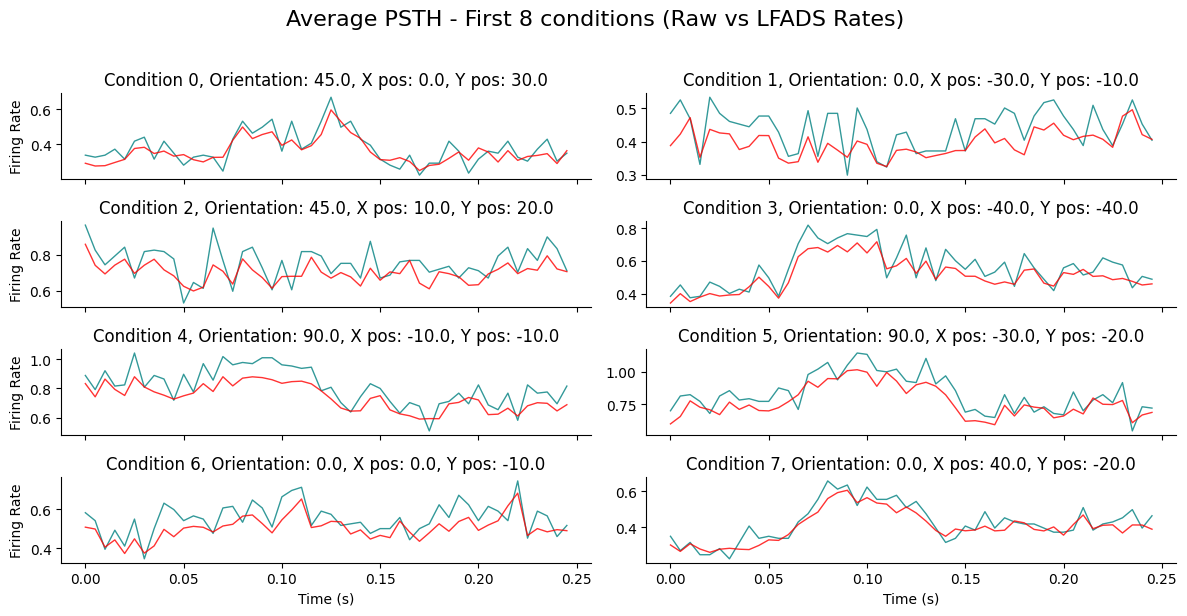

In [175]:
def plot_mean_by_condition(spikes_data, rates_data, title):
    # Create a 4x2 grid to fit exactly 8 neurons
    fig, axes = plt.subplots(4, 2, figsize=(12, 6), sharex=True)
    time = np.arange(0, 0.25, 0.005)
    
    # Flatten the axes array to easily iterate through all 8 subplots
    axes_flat = axes.flatten()
    
    for i in range(8):
        ax = axes_flat[i]
        
        # Calculate the mean across all trials for the i-th condition
        spikes_mean_activity = np.mean(spikes_data[i], axis=1)
        rates_mean_activity = np.mean(rates_data[i], axis=1)
        
        ax.plot(time, spikes_mean_activity/bin_width_sec, color='teal', linewidth=1, alpha=0.8)
        ax.plot(time, rates_mean_activity/bin_width_sec, color='red', linewidth=1, alpha=0.8)
        ax.set_title(f"Condition {i}, Orientation: {stimulus_id_map[i][0]}, X pos: {stimulus_id_map[i][1]}, Y pos: {stimulus_id_map[i][2]}", fontsize=12)
        
        # Clean up visual clutter
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add labels only to the bottom-most plots for a cleaner look
        if i >= 6:
            ax.set_xlabel("Time (s)")
        if i % 2 == 0:
            ax.set_ylabel("Firing Rate")

    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Run the updated plotting function
plot_mean_by_condition(mean_spikes, mean_rates, "Average PSTH - First 8 conditions (Raw vs LFADS Rates)")

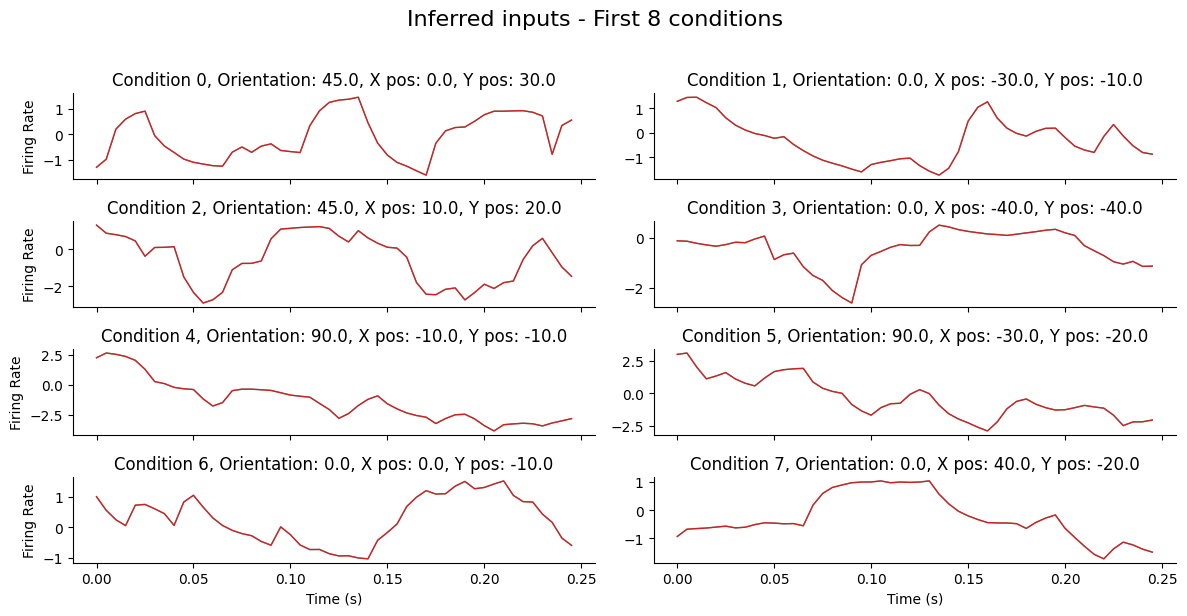

In [163]:
plot_mean_by_condition(mean_inputs, mean_inputs, title='Inferred inputs - First 8 conditions')

In [164]:
from matplotlib.colors import hsv_to_rgb

def plot_pca_2d(data_array, property_dict, title='PCA Projection', option=0):
    n_trials = data_array.shape[0]
    reshaped_data = data_array.reshape(n_trials, -1)
    
    # 1. Convert dict to array [x, y, orientation]
    prop_map = np.array([property_dict[i] for i in range(n_trials)])
    
    # 2. Run PCA
    pca = PCA(n_components=2)
    pca_results = pca.fit_transform(reshaped_data)
    var_explained = pca.explained_variance_ratio_ * 100
    
    # 3. Rescale X and Y to [0, 1] for Red and Green channels
    def rescale(vec):
        if vec.max() == vec.min(): return np.zeros_like(vec)
        return (vec - vec.min()) / (vec.max() - vec.min())

    r = rescale(prop_map[:, 1]) # X -> Red
    b = rescale(prop_map[:, 2]) # Y -> blue
    g = [0]*243

    # 4. Visualization
    fig, ax = plt.subplots(figsize=(10, 8))

    if option == 0:     # x y ori
        markers = ['o', 's', '^']
    elif option == 1:       # x y pos
        markers = ['o', 'o', 'o']
    elif option == 2:       # ori
        markers = ['o', 'o', 'o']
        r = rescale(prop_map[:, 0])
        g = b = [0]*243
    
    colors = np.stack([r, g, b], axis=1)
    unique_oris = np.unique(prop_map[:, 0])

    for idx, ori in enumerate(unique_oris):
        mask = prop_map[:, 0] == ori
        
        ax.scatter(
            pca_results[mask, 0], pca_results[mask, 1], 
            c=colors[mask], 
            marker=markers[idx],
            s=120, 
            edgecolors='white', 
            linewidths=0.5,
            alpha=0.7,
            label=f'Orientation: {ori}'
        )

    ax.set_title(title, fontsize=15)
    ax.set_xlabel(f'PC 1 ({var_explained[0]:.1f}% Var)')
    ax.set_ylabel(f'PC 2 ({var_explained[1]:.1f}% Var)')
    ax.legend(loc='upper right')
    
    return fig, ax

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'PCA projection of latent factors'}, xlabel='PC 1 (22.0% Var)', ylabel='PC 2 (3.7% Var)'>)

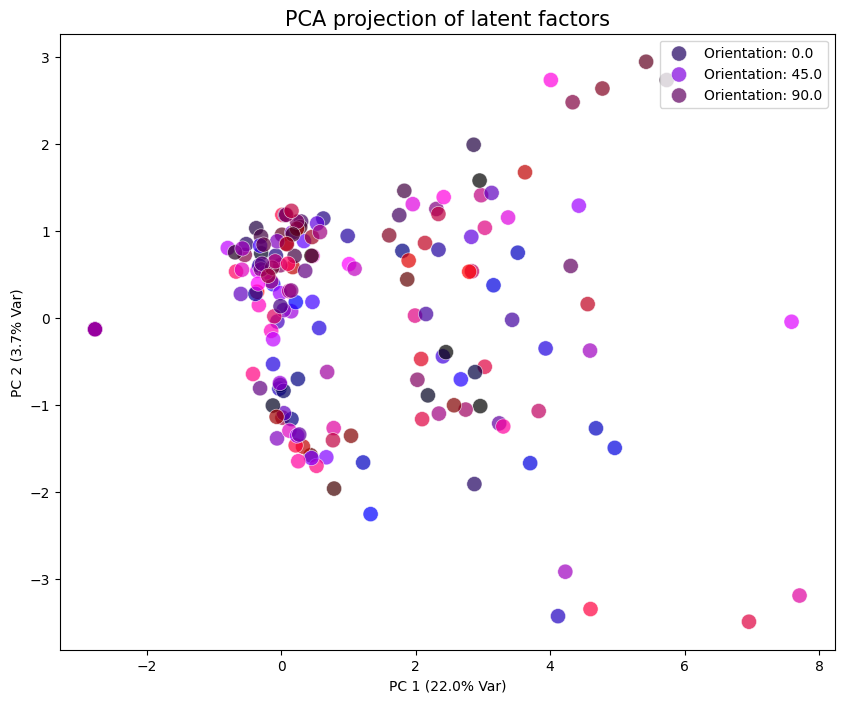

In [165]:
plot_pca_2d(mean_factors, stimulus_id_map, title="PCA projection of latent factors", option=1)

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'PCA projection of inferred inputs'}, xlabel='PC 1 (19.2% Var)', ylabel='PC 2 (14.0% Var)'>)

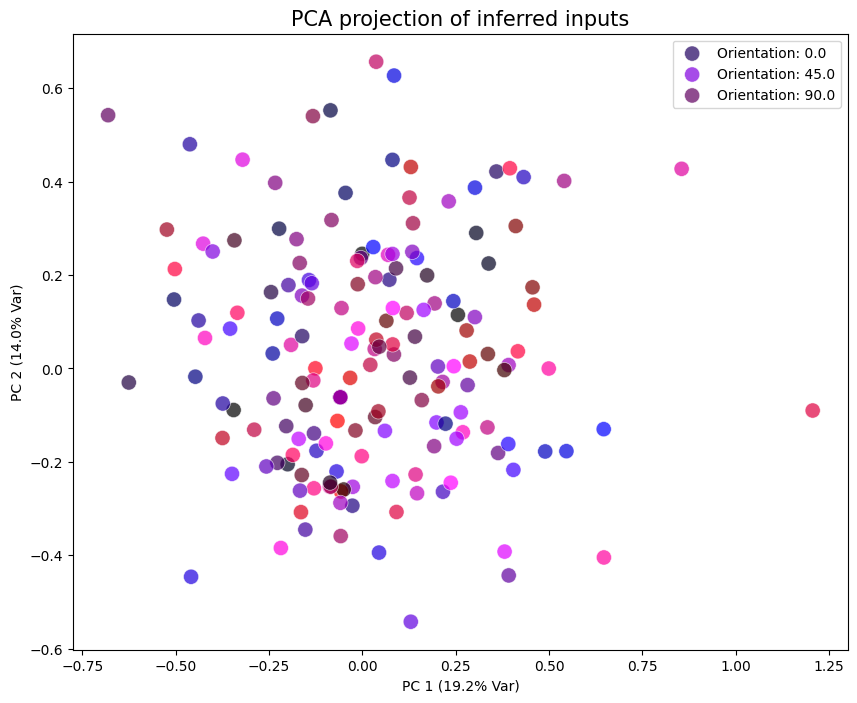

In [166]:
plot_pca_2d(mean_inputs, stimulus_id_map, title="PCA projection of inferred inputs", option=1)

In [237]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.lines as mlines

def plot_pca_3d(data_array, property_dict, title='3D PCA Projection', option=0, elev=45, azim=45):
    n_trials = data_array.shape[0]
    reshaped_data = data_array.reshape(n_trials, -1)
    
    prop_map = np.array([property_dict[i] for i in range(n_trials)])
    
    pca = PCA(n_components=3)
    pca_results = pca.fit_transform(reshaped_data)
    var_explained = pca.explained_variance_ratio_ * 100
    
    def rescale(vec):
        if vec.max() == vec.min(): return np.zeros_like(vec)
        return (vec - vec.min()) / (vec.max() - vec.min())

    # Map colors
    r = rescale(prop_map[:, 1]) # X -> Red
    b = rescale(prop_map[:, 2]) # Y -> Blue
    g = np.zeros(n_trials)      # Green -> 0

    if option == 0:     # x y ori
        markers = ['o', 's', '^']
        legend_title = "Orientation"
    elif option == 1:   # x y pos
        markers = ['o', 'o', 'o']
        legend_title = "Spatial Mapping"
    elif option == 2:   # ori only color
        markers = ['o', 'o', 'o']
        r = rescale(prop_map[:, 0])
        b = g = np.zeros(n_trials)
        legend_title = "Orientation Color"
    
    colors = np.stack([r, g, b], axis=1)
    unique_oris = np.unique(prop_map[:, 0])

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    for idx, ori in enumerate(unique_oris):
        mask = prop_map[:, 0] == ori
        ax.scatter(
            pca_results[mask, 0], 
            pca_results[mask, 1], 
            pca_results[mask, 2],
            c=colors[mask], 
            marker=markers[idx % len(markers)],
            s=60, 
            edgecolors='white', 
            linewidths=0.3,
            alpha=0.8,
            label=f'Orientation: {ori}' if option != 1 else None
        )

    # --- Option 1 Custom Legend ---
    if option == 1:
        # Create "proxy" artists for the legend
        red_patch = mlines.Line2D([], [], color='red', marker='s', linestyle='None', label='Red: X')
        blue_patch = mlines.Line2D([], [], color='blue', marker='s', linestyle='None', label='Blue: Y')
        black_patch = mlines.Line2D([], [], color='black', marker='s', linestyle='None', label='Black: $X_{min}$, $Y_{min}$')
        magenta_patch = mlines.Line2D([], [], color='magenta', marker='s', linestyle='None', label='Magenta: $X_{max}$, $Y_{max}$')
        
        # ax.legend(handles=[red_patch, blue_patch, black_patch, magenta_patch], 
        #           title="Color Mapping (RGB)", loc='upper right', bbox_to_anchor=(1.0, 1.0))
    else:
        ax.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0), title=legend_title)

    ax.set_title(title, fontsize=15)
    ax.set_xlabel(f'PC 1 ({var_explained[0]:.1f}%)')
    ax.set_ylabel(f'PC 2 ({var_explained[1]:.1f}%)')
    ax.set_zlabel(f'PC 3 ({var_explained[2]:.1f}%)')
    
    ax.view_init(elev=elev, azim=azim)
    
    return fig, ax

(<Figure size 1200x1000 with 1 Axes>,
 <Axes3D: title={'center': 'PCA projection of latent factors'}, xlabel='PC 1 (22.0%)', ylabel='PC 2 (3.7%)', zlabel='PC 3 (2.8%)'>)

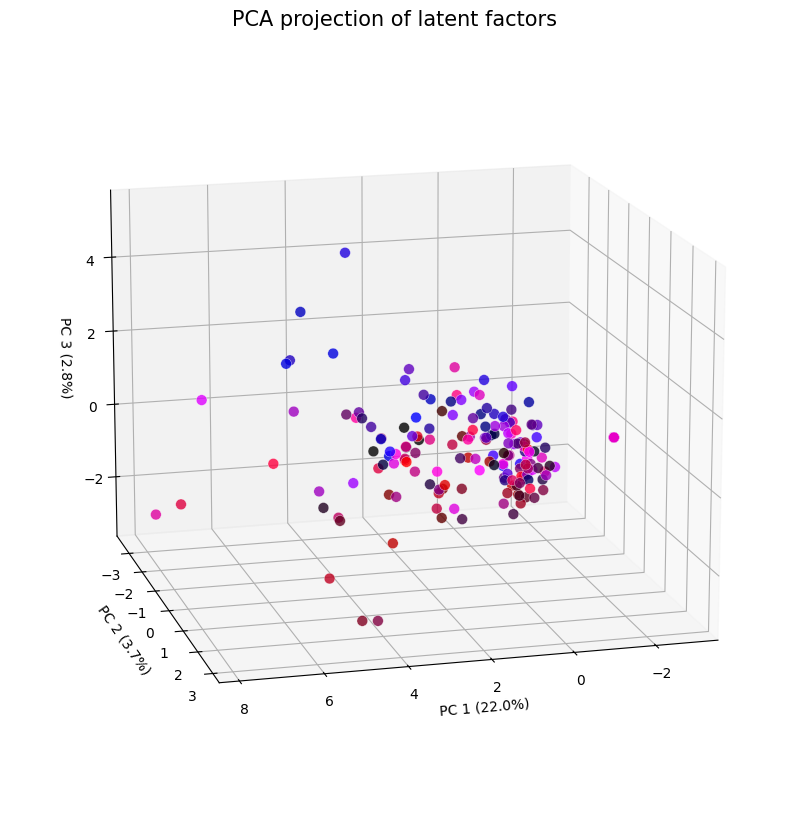

In [238]:
plot_pca_3d(mean_factors, stimulus_id_map, title="PCA projection of latent factors", option=1, elev=15, azim=75)

(<Figure size 1200x1000 with 1 Axes>,
 <Axes3D: title={'center': 'PCA projection of inferred inputs'}, xlabel='PC 1 (19.2%)', ylabel='PC 2 (14.0%)', zlabel='PC 3 (9.4%)'>)

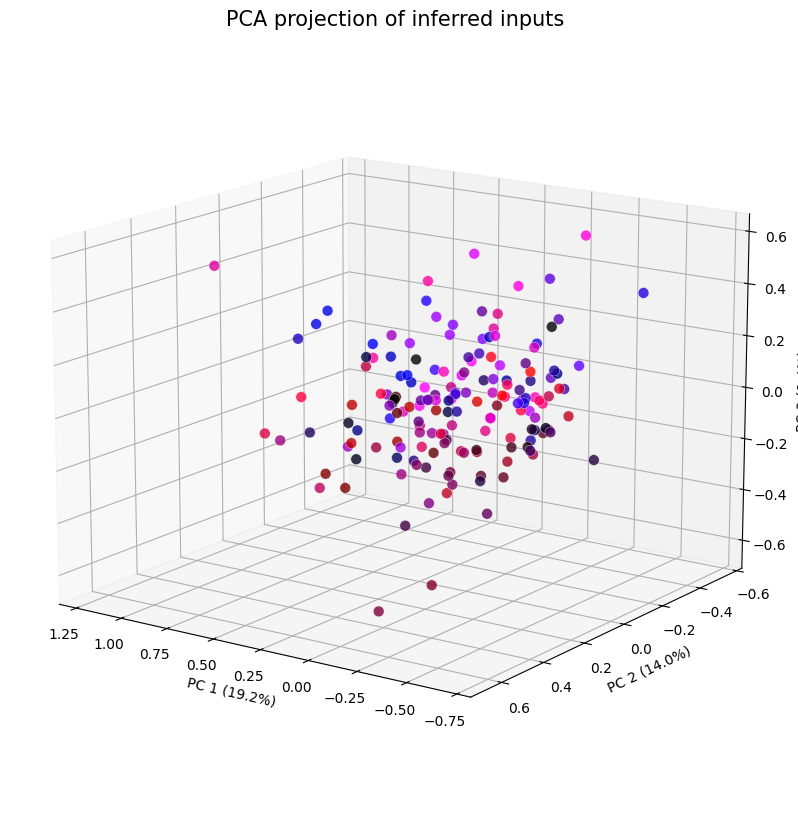

In [239]:
plot_pca_3d(mean_inputs, stimulus_id_map, title="PCA projection of inferred inputs", option=1, elev=15, azim=125)

In [194]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE # Import t-SNE
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.lines as mlines

def plot_tsne_3d(data_array, property_dict, title='3D t-SNE Projection', option=0, elev=45, azim=45, perplexity=30):
    n_trials = data_array.shape[0]
    reshaped_data = data_array.reshape(n_trials, -1)
    
    # 1. Convert dict to array [x, y, orientation]
    prop_map = np.array([property_dict[i] for i in range(n_trials)])
    
    # 2. Run t-SNE (Note: t-SNE doesn't have "variance explained" like PCA)
    tsne = TSNE(
        n_components=3, 
        perplexity=perplexity, 
        init='pca', 
        learning_rate='auto', 
        random_state=42
    )
    tsne_results = tsne.fit_transform(reshaped_data)
    
    # 3. Rescale logic for colors
    def rescale(vec):
        if vec.max() == vec.min(): return np.zeros_like(vec)
        return (vec - vec.min()) / (vec.max() - vec.min())

    # Map colors
    r = rescale(prop_map[:, 1]) # X -> Red
    b = rescale(prop_map[:, 2]) # Y -> Blue
    g = np.zeros(n_trials)      # Green -> 0

    if option == 0:     # x y ori
        markers = ['o', 's', '^']
        legend_title = "Orientation"
    elif option == 1:   # x y pos
        markers = ['o', 'o', 'o']
        legend_title = "Spatial Mapping"
    elif option == 2:   # ori only color
        markers = ['o', 'o', 'o']
        r = rescale(prop_map[:, 0])
        b = g = np.zeros(n_trials)
        legend_title = "Orientation Color"
    
    colors = np.stack([r, g, b], axis=1)
    unique_oris = np.unique(prop_map[:, 0])

    # 4. 3D Visualization
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    for idx, ori in enumerate(unique_oris):
        mask = prop_map[:, 0] == ori
        ax.scatter(
            tsne_results[mask, 0], 
            tsne_results[mask, 1], 
            tsne_results[mask, 2],
            c=colors[mask], 
            marker=markers[idx % len(markers)],
            s=60, 
            edgecolors='white', 
            linewidths=0.3,
            alpha=0.8,
            label=f'Orientation: {ori}' if option != 1 else None
        )

    # Custom Legend for Option 1
    if option == 1:
        red_patch = mlines.Line2D([], [], color='red', marker='s', linestyle='None', label='Red: X')
        blue_patch = mlines.Line2D([], [], color='blue', marker='s', linestyle='None', label='Blue: Y')
        black_patch = mlines.Line2D([], [], color='black', marker='s', linestyle='None', label='Black: $X_{min}$, $Y_{min}$')
        magenta_patch = mlines.Line2D([], [], color='magenta', marker='s', linestyle='None', label='Magenta: $X_{max}$, $Y_{max}$')
        ax.legend(handles=[red_patch, blue_patch, black_patch, magenta_patch], 
                  title="Color Mapping (RGB)", loc='upper right', bbox_to_anchor=(1.25, 1))
    else:
        ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1), title=legend_title)

    ax.set_title(title, fontsize=15)
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.set_zlabel('t-SNE 3')
    
    ax.view_init(elev=elev, azim=azim)
    
    return fig, ax

(<Figure size 1200x1000 with 1 Axes>,
 <Axes3D: title={'center': 'tSNE projection of latent factors'}, xlabel='t-SNE 1', ylabel='t-SNE 2', zlabel='t-SNE 3'>)

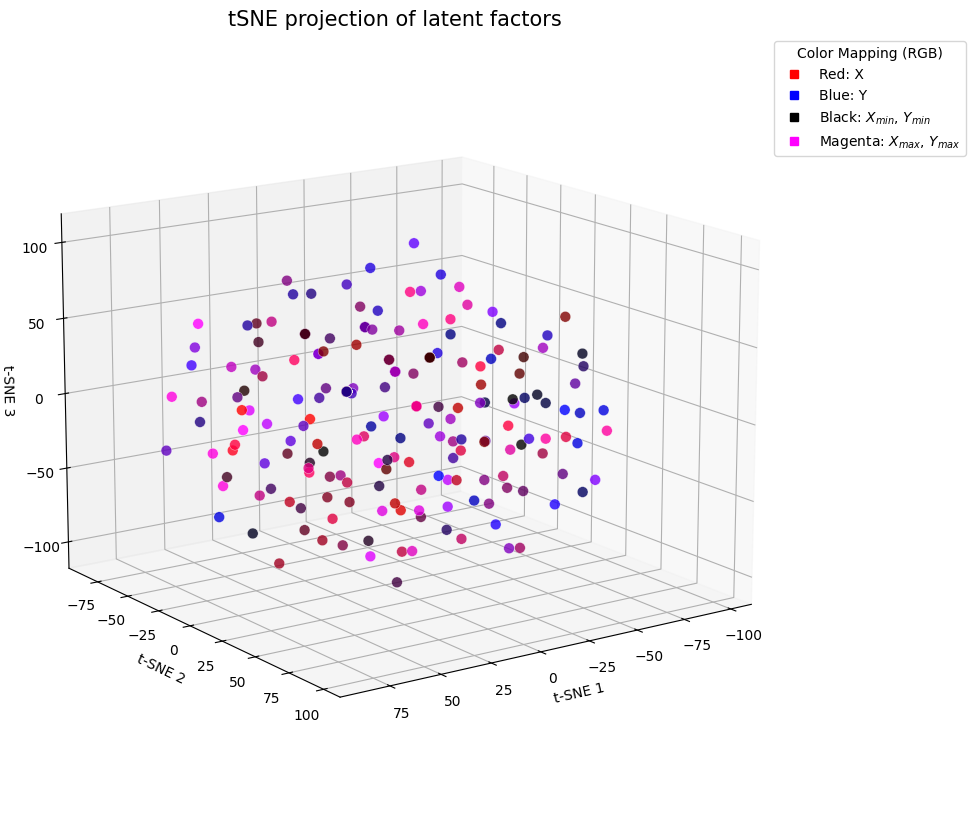

In [209]:
plot_tsne_3d(mean_factors, stimulus_id_map, title="tSNE projection of latent factors", option=1, elev=15, azim=55, perplexity=70)

(<Figure size 1200x1000 with 1 Axes>,
 <Axes3D: title={'center': 'tSNE projection of inferred inputs'}, xlabel='t-SNE 1', ylabel='t-SNE 2', zlabel='t-SNE 3'>)

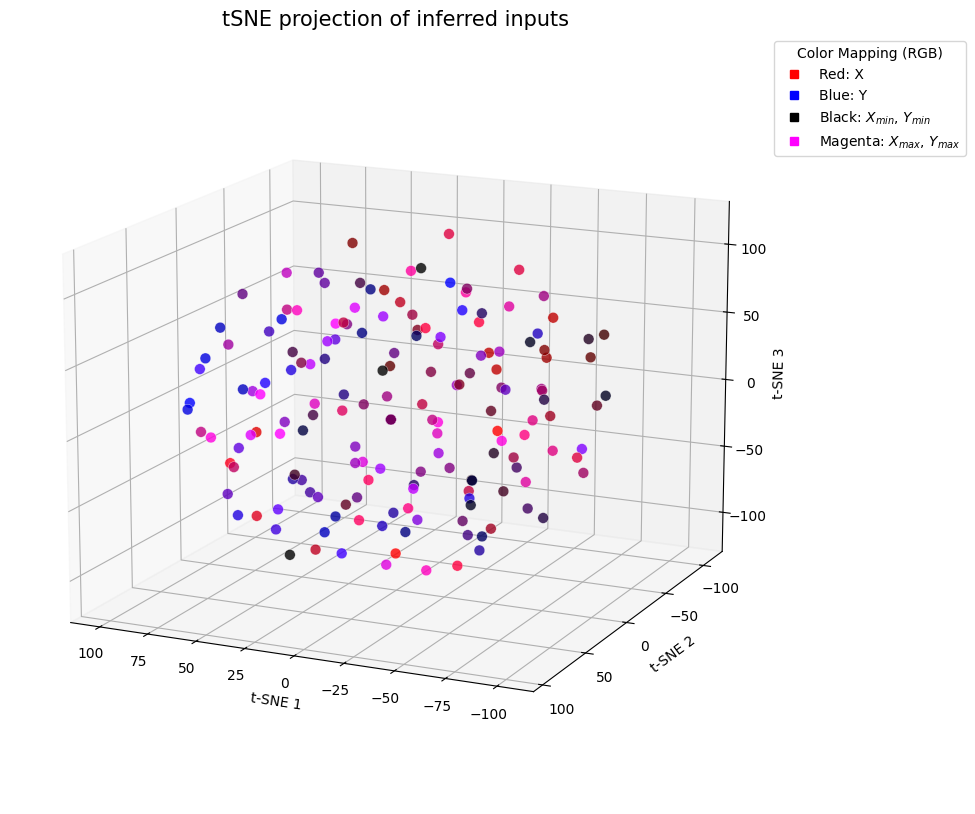

In [208]:
plot_tsne_3d(mean_inputs, stimulus_id_map, title="tSNE projection of inferred inputs", option=1, elev=15, azim=115, perplexity=70)

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Colour spatial map'}, xlabel='X (red)', ylabel='Y (blue)'>)

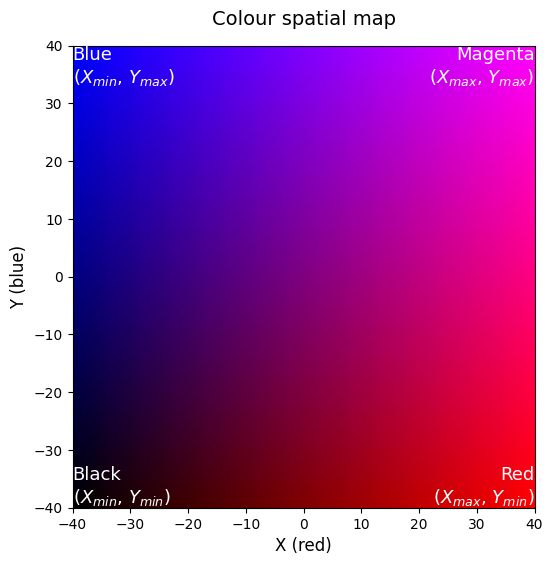

In [207]:
import numpy as np
import matplotlib.pyplot as plt

def plot_spatial_color_legend(x_min, x_max, y_min, y_max, resolution=100):
    """
    Creates a 2D square legend showing how (X, Y) coordinates 
    map to (Red, Blue) colors.
    """
    # 1. Create a grid of coordinates
    x_coords = np.linspace(x_min, x_max, resolution)
    y_coords = np.linspace(y_min, y_max, resolution)
    
    # meshgrid creates 2D arrays of coordinates
    # indexing='ij' ensures X is horizontal and Y is vertical
    X, Y = np.meshgrid(x_coords, y_coords)

    # 2. Replicate your 'rescale' logic
    # Maps min->0 and max->1
    R = (X - x_min) / (x_max - x_min)
    B = (Y - y_min) / (y_max - y_min)
    G = np.zeros_like(R) # Green is 0 as per your mapping

    # 3. Stack into an RGB image (Height, Width, 3)
    # We flip the Y axis (origin='lower') so y_min is at the bottom
    color_grid = np.stack([R, G, B], axis=2)

    # 4. Visualization
    fig, ax = plt.subplots(figsize=(6, 6))
    
    img = ax.imshow(
        color_grid, 
        extent=[x_min, x_max, y_min, y_max], 
        origin='lower',
        aspect='equal'
    )

    ax.set_title("Colour spatial map", fontsize=14, pad=15)
    ax.set_xlabel("X (red)", fontsize=12)
    ax.set_ylabel("Y (blue)", fontsize=12)
    
    # Add labels to the corners for absolute clarity
    ax.text(x_min, y_min, 'Black\n($X_{min}$, $Y_{min}$)', color='white', ha='left', va='bottom', fontsize=13)
    ax.text(x_max, y_min, 'Red\n($X_{max}$, $Y_{min}$)', color='white', ha='right', va='bottom', fontsize=13)
    ax.text(x_min, y_max, 'Blue\n($X_{min}$, $Y_{max}$)', color='white', ha='left', va='top', fontsize=13)
    ax.text(x_max, y_max, 'Magenta\n($X_{max}$, $Y_{max}$)', color='white', ha='right', va='top', fontsize=13)

    plt.grid(False) # Ensure grid lines don't distract
    return fig, ax

# Example usage with your specific bounds:
plot_spatial_color_legend(x_min=-40, x_max=40, y_min=-40, y_max=40)

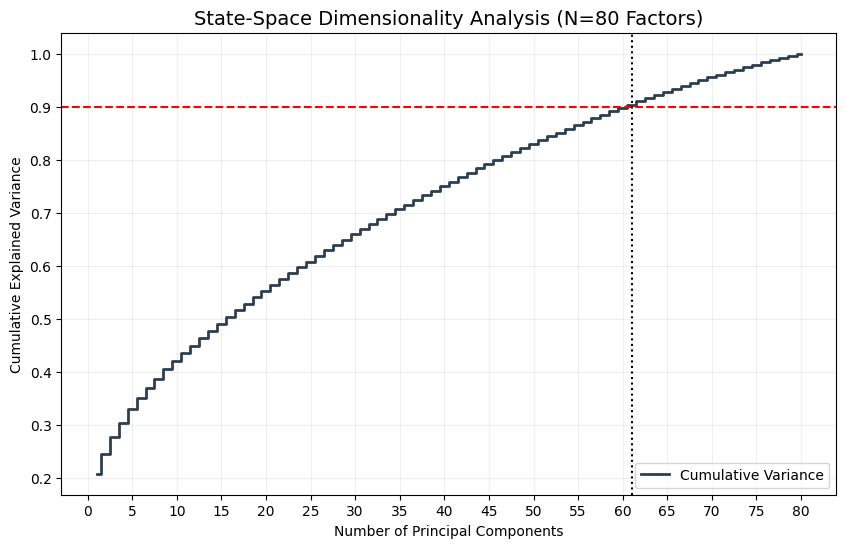

--- State-Space Analysis ---
Total Factors in Model: 80
Intrinsic Dimensionality (>90%): 61


In [170]:
def analyze_pca_variance(data_array, threshold=0.90):
    """
    Analyzes dimensionality across the 'Factors' dimension.
    data_array: (n_trials, n_timepoints, n_factors)
    """
    # 1. Reshape: Stack all trials and timepoints
    # Resulting shape: (Total_Timepoints, n_factors)
    n_trials, n_time, n_factors = data_array.shape
    state_space_data = data_array.reshape(-1, n_factors)
    
    # 2. Fit PCA on the factor dimension
    pca = PCA()
    pca.fit(state_space_data)
    
    # 3. Calculate Variance Metrics
    exp_var_ratio = pca.explained_variance_ratio_
    cumulative_var = np.cumsum(exp_var_ratio)
    
    # 4. Find threshold
    n_pcs_needed = np.argmax(cumulative_var >= threshold) + 1
    
    # 5. Plotting
    plt.figure(figsize=(10, 6))
    plt.step(range(1, len(cumulative_var) + 1), cumulative_var, where='mid',
             label='Cumulative Variance', color='#2c3e50', lw=2)


    plt.axhline(y=threshold, color='r', linestyle='--')
    plt.axvline(x=n_pcs_needed, color='black', linestyle=':')
    
    plt.title(f'State-Space Dimensionality Analysis (N={n_factors} Factors)', fontsize=14)
    plt.ylabel('Cumulative Explained Variance')
    plt.xlabel('Number of Principal Components')
    plt.xticks(range(0, n_factors + 1, 5))
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.2)
    plt.show()

    print(f"--- State-Space Analysis ---")
    print(f"Total Factors in Model: {n_factors}")
    print(f"Intrinsic Dimensionality (>{int(threshold*100)}%): {n_pcs_needed}")
    
    return n_pcs_needed

# Example usage with your LFADS factors:
results = analyze_pca_variance(mean_factors)

# Inferred inputs analysis

### plot inferred inputs, EAA vs control

In [171]:
# plot inferred inputs for each condition

def plot_inferred_inputs_by_group(input_data_EAA, input_data_Ctr, title):
    # Create a 2x2 grid to fit exactly 4 conditions
    fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
    conditions = ['Danger', 'Uncertain shock', 'Uncertain no shock', 'Safe']
    
    # Flatten the axes array to easily iterate through all 4 subplots
    axes_flat = axes.flatten()

    inputs_EAA_danger = np.mean(input_data_EAA[0:4, :, :], axis=(0, 2))
    inputs_EAA_unc_noshock = np.mean(input_data_EAA[4:6, :, :], axis=(0, 2))
    inputs_EAA_unc_shock = np.mean(input_data_EAA[6:11, :, :], axis=(0, 2))
    inputs_EAA_safety = np.mean(input_data_EAA[11:15, :, :], axis=(0, 2))
    inputs_EAA = [inputs_EAA_danger, inputs_EAA_unc_noshock, inputs_EAA_unc_shock, inputs_EAA_safety]

    inputs_Ctr_danger = np.mean(input_data_Ctr[0:4, :, :], axis=(0, 2))
    inputs_Ctr_unc_noshock = np.mean(input_data_Ctr[4:6, :, :], axis=(0, 2))
    inputs_Ctr_unc_shock = np.mean(input_data_Ctr[6:11, :, :], axis=(0, 2))
    inputs_Ctr_safety = np.mean(input_data_Ctr[11:15, :, :], axis=(0, 2))
    inputs_Ctr = [inputs_Ctr_danger, inputs_Ctr_unc_noshock, inputs_Ctr_unc_shock, inputs_Ctr_safety]
    
    for i in range(4):
        ax = axes_flat[i]
        ax.axvline(x=170, label='Shock', color='grey', linestyle='--', linewidth=0.8)
        ax.axvline(x=50, label='Cue onset', color='red', linestyle='--', linewidth=0.8)
        ax.axvline(x=150, label='Cue offset', color='blue', linestyle='--', linewidth=0.8)
        ax.plot(inputs_EAA[i], color='purple', linewidth=1, alpha=0.9, label='EAA')
        ax.plot(inputs_Ctr[i], color='green', linewidth=1, alpha=0.9, label='Control')
        ax.set_title(conditions[i], fontsize=12)
        
        if i == 0:
            ax.legend()
        
        # Clean up visual clutter
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add labels only to the bottom-most plots for a cleaner look
        if i >= 2:
            ax.set_xlabel("Timestep")
        if i % 2 == 0:
            ax.set_ylabel("Mean firing rate")

    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Run the updated plotting function
plot_inferred_inputs_by_group(inferred_inputs['EAA'], inferred_inputs['Ctr'], "Inferred inputs by condition (mean across all neurons)")

KeyError: 'EAA'

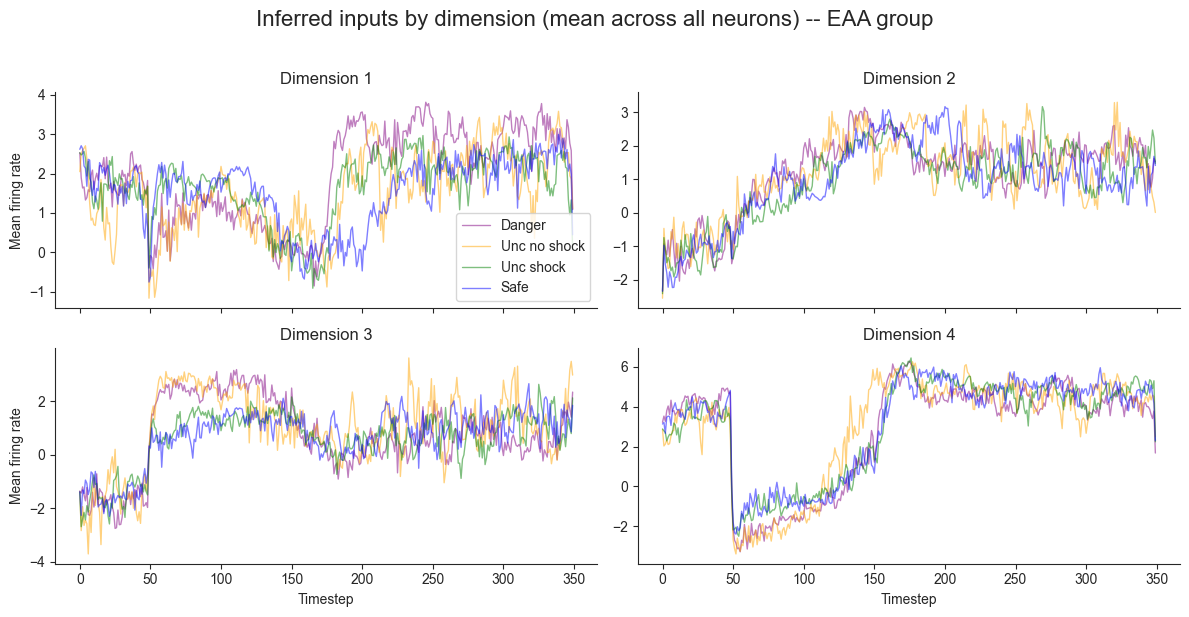

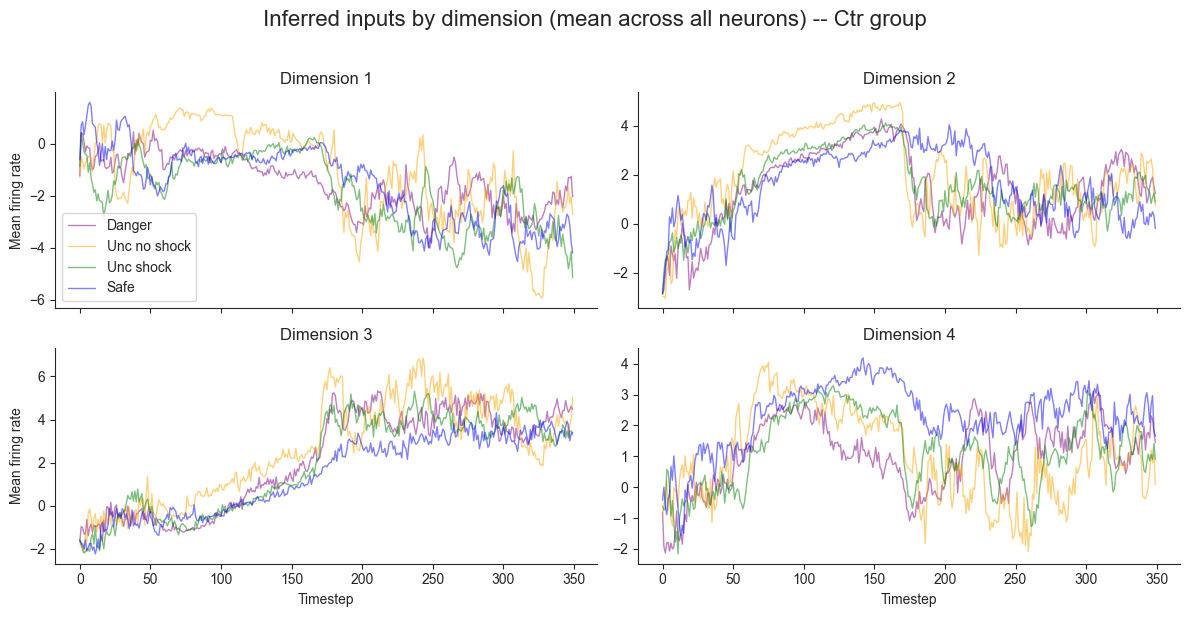

In [ ]:
# plot 4 conditions for each dimension of inferred inputs

def plot_inferred_inputs_by_dimension(input_data, title):
    # Create a 2x2 grid to fit exactly 4 dimensions
    fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
    dimensions = ['Dimension 1', 'Dimension 2', 'Dimension 3', 'Dimension 4']
    
    # Flatten the axes array to easily iterate through all 4 subplots
    axes_flat = axes.flatten()

    inputs_dim0_danger = np.mean(input_data[0:4, :, 0:1], axis=0)
    inputs_dim0_unc_noshock = np.mean(input_data[4:6, :, 0:1], axis=0)
    inputs_dim0_unc_shock = np.mean(input_data[6:11, :, 0:1], axis=0)
    inputs_dim0_safety = np.mean(input_data[11:15, :, 0:1], axis=0)

    inputs_dim1_danger = np.mean(input_data[0:4, :, 1:2], axis=0)
    inputs_dim1_unc_noshock = np.mean(input_data[4:6, :, 1:2], axis=0)
    inputs_dim1_unc_shock = np.mean(input_data[6:11, :, 1:2], axis=0)
    inputs_dim1_safety = np.mean(input_data[11:15, :, 1:2], axis=0)

    inputs_dim2_danger = np.mean(input_data[0:4, :, 2:3], axis=0)
    inputs_dim2_unc_noshock = np.mean(input_data[4:6, :, 2:3], axis=0)
    inputs_dim2_unc_shock = np.mean(input_data[6:11, :, 2:3], axis=0)
    inputs_dim2_safety = np.mean(input_data[11:15, :, 2:3], axis=0)

    inputs_dim3_danger = np.mean(input_data[0:4, :, 3:4], axis=0)
    inputs_dim3_unc_noshock = np.mean(input_data[4:6, :, 3:4], axis=0)
    inputs_dim3_unc_shock = np.mean(input_data[6:11, :, 3:4], axis=0)
    inputs_dim3_safety = np.mean(input_data[11:15, :, 3:4], axis=0)

    danger = [inputs_dim0_danger, inputs_dim1_danger, inputs_dim2_danger, inputs_dim3_danger]
    unc_noshock = [inputs_dim0_unc_noshock, inputs_dim1_unc_noshock, inputs_dim2_unc_noshock, inputs_dim3_unc_noshock]
    unc_shock = [inputs_dim0_unc_shock, inputs_dim1_unc_shock, inputs_dim2_unc_shock, inputs_dim3_unc_shock]
    safety = [inputs_dim0_safety, inputs_dim1_safety, inputs_dim2_safety, inputs_dim3_safety]

    for i in range(4):
        ax = axes_flat[i]
        
        ax.plot(danger[i], color='purple', linewidth=1, alpha=0.5, label='Danger')
        ax.plot(unc_noshock[i], color='orange', linewidth=1, alpha=0.5, label='Unc no shock')
        ax.plot(unc_shock[i], color='green', linewidth=1, alpha=0.5, label='Unc shock')
        ax.plot(safety[i], color='blue', linewidth=1, alpha=0.5, label='Safe')
        ax.set_title(dimensions[i], fontsize=12)
        
        if i == 0:
            ax.legend()
        
        # Clean up visual clutter
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add labels only to the bottom-most plots for a cleaner look
        if i >= 2:
            ax.set_xlabel("Timestep")
        if i % 2 == 0:
            ax.set_ylabel("Mean firing rate")

    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Run the updated plotting function
plot_inferred_inputs_by_dimension(inferred_inputs['EAA'], "Inferred inputs by dimension (mean across all neurons) -- EAA group")
plot_inferred_inputs_by_dimension(inferred_inputs['Ctr'], "Inferred inputs by dimension (mean across all neurons) -- Ctr group")

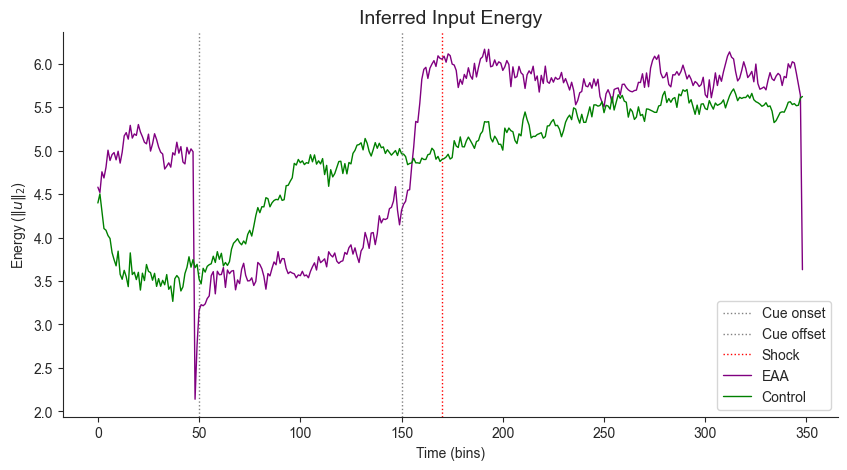

In [ ]:
def plot_input_energy(inputs_EAA, inputs_Ctr, title="Inferred Input Energy", axes=None):
    """
    Calculates and plots the L2 norm (energy) of inferred inputs over time.
    
    Parameters:
        inputs: np.array of shape (n_trials, n_time, n_inputs)
        title: string for the plot title
        axes: optional matplotlib axis for subplot integration
    """
    # 1. Calculate Energy: Square the inputs, sum across dimensions, then sqrt
    # shape results in (n_trials, n_time)
    energy_EAA = np.linalg.norm(inputs_EAA, axis=2)
    energy_Ctr = np.linalg.norm(inputs_Ctr, axis=2)
    
    # 2. Calculate mean and standard error across trials
    mean_energy_EAA = np.mean(energy_EAA, axis=0)
    mean_energy_Ctr = np.mean(energy_Ctr, axis=0)
    time_points = np.arange(inputs_EAA.shape[1])

    # 3. Plotting
    if axes is None:
        fig, ax = plt.subplots(figsize=(10, 5))
    else:
        ax = axes

    ax.axvline(50, color='grey', linestyle=':', linewidth=1, label='Cue onset')
    ax.axvline(150, color='grey', linestyle=':', linewidth=1, label='Cue offset')
    ax.axvline(170, color='red', linestyle=':', linewidth=1, label='Shock')
    ax.plot(time_points, mean_energy_EAA, color='purple', lw=1, label='EAA')
    ax.plot(time_points, mean_energy_Ctr, color='green', lw=1, label='Control')


    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Time (bins)")
    ax.set_ylabel("Energy ($\|u\|_2$)")
    ax.legend()
    sns.despine(ax=ax)
    
    if axes is None:
        plt.show()

# Example usage:
plot_input_energy(inferred_inputs['EAA'][:, 1: ,], inferred_inputs['Ctr'][:, 1: ,])

In [ ]:
inferred_inputs['EAA'].shape

(32, 350, 4)

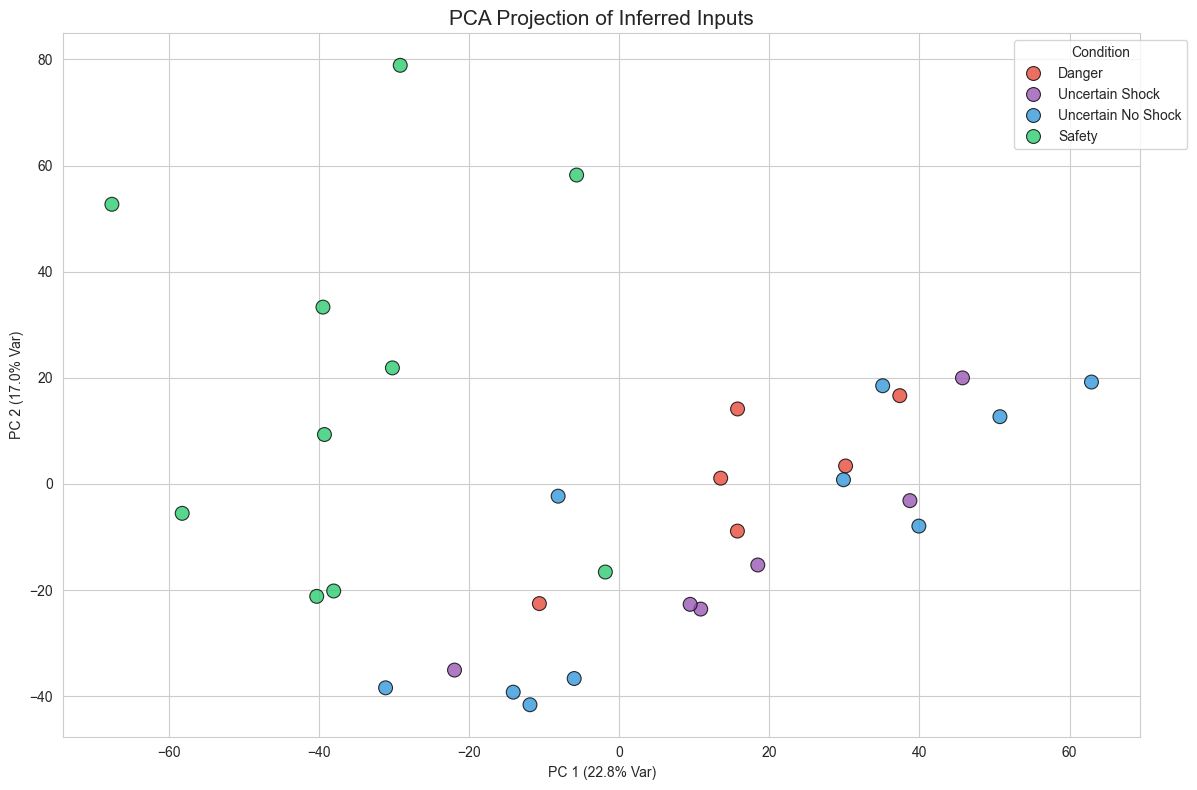

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

def plot_pca_stacked_inputs(data_array):
    """
    Reshapes data from (Trials, Time, Inputs) to (Trials * Inputs, Time)
    and performs PCA to compare with t-SNE results.
    """
    # 1. Reshape: (16, 400, 4) -> (16, 4, 400) -> (64, 400)
    n_trials, n_time, n_inputs = data_array.shape
    reshaped_data = data_array.reshape(n_trials, -1)

    # 2. Define labels for the 64 points (Same as your t-SNE script)
    base_conditions = (
        ['Danger'] * 6 + 
        ['Uncertain Shock'] * 6 + 
        ['Uncertain No Shock'] * 10 + 
        ['Safety'] * 10
    )

    # 3. Run PCA
    pca = PCA(n_components=2)
    pca_results = pca.fit_transform(reshaped_data)
    var_explained = pca.explained_variance_ratio_ * 100

    # 4. Visualization
    plt.figure(figsize=(12, 8))
    sns.set_style("whitegrid")
    
    palette = {
        'Danger': '#e74c3c', 
        'Uncertain Shock': '#9b59b6', 
        'Uncertain No Shock': '#3498db',
        'Safety': '#2ecc71'
    }

    sns.scatterplot(
        x=pca_results[:, 0], 
        y=pca_results[:, 1], 
        hue=base_conditions,
        palette=palette,
        s=100,
        alpha=0.8,
        edgecolor='black'
    )

    plt.title('PCA Projection of Inferred Inputs', fontsize=15)
    plt.xlabel(f'PC 1 ({var_explained[0]:.1f}% Var)')
    plt.ylabel(f'PC 2 ({var_explained[1]:.1f}% Var)')
    plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper right')
    plt.tight_layout()
    plt.show()

# Run the PCA comparison
plot_pca_stacked_inputs(inferred_inputs['Ctr'])

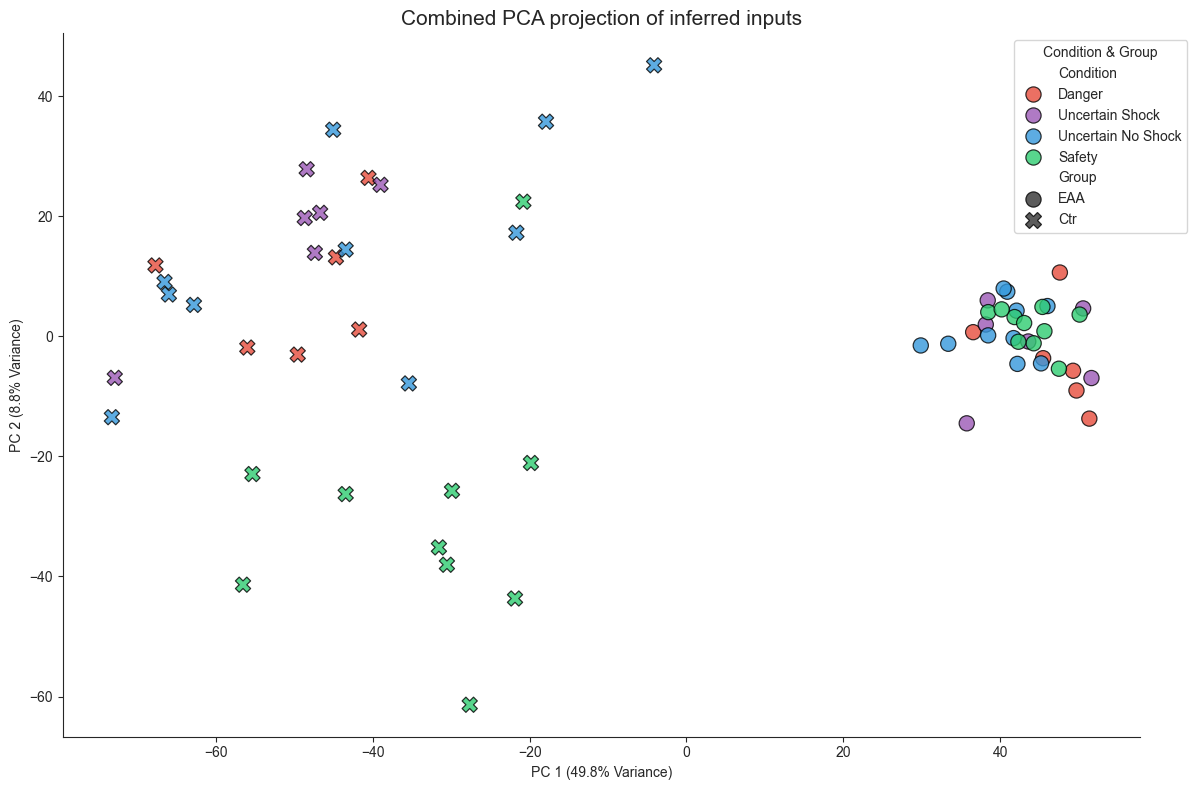

In [ ]:
plot_pca_combined(inferred_inputs['EAA'][:, 125:, :], inferred_inputs['Ctr'][:, 125:, :])

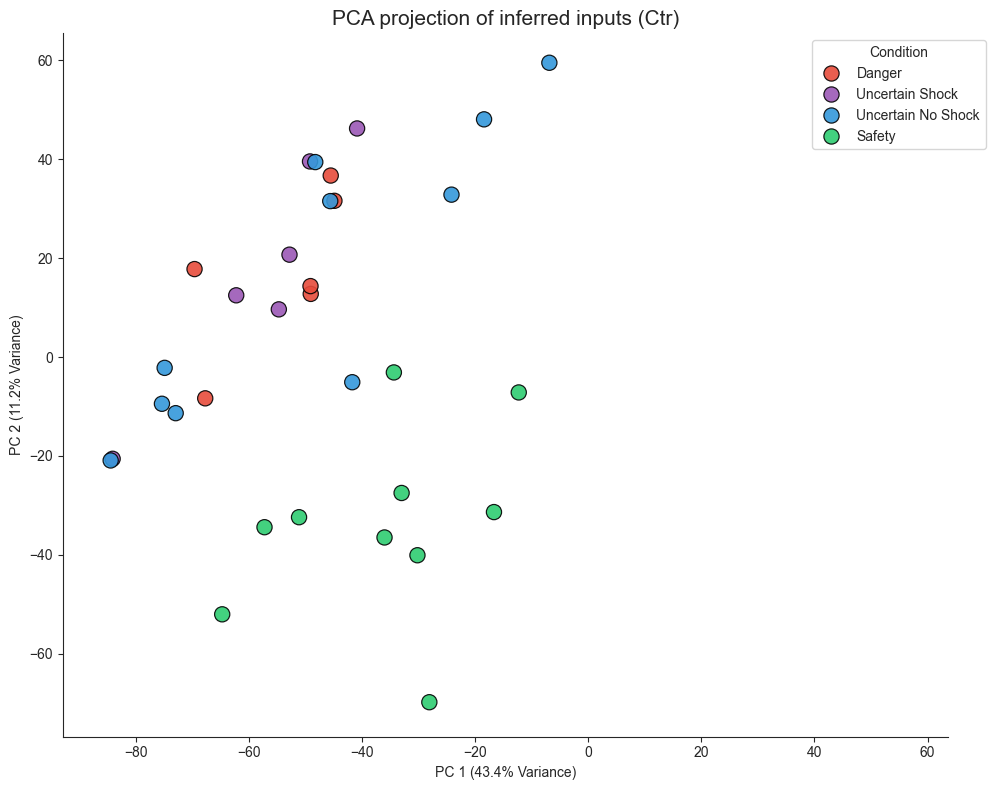

In [ ]:
plot_pca(inferred_inputs['EAA'], inferred_inputs['Ctr'], title='PCA projection of inferred inputs (Ctr)', group='Ctr')

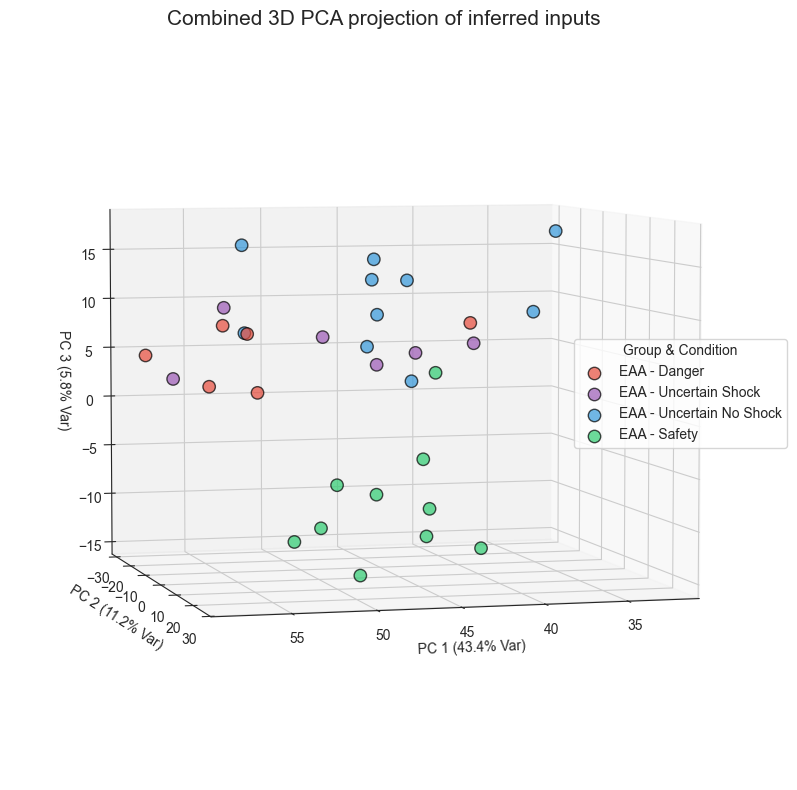

In [ ]:
plot_pca_combined_3d(inferred_inputs['EAA'], inferred_inputs['Ctr'], 'Combined 3D PCA projection of inferred inputs', elev=5, azim=75)

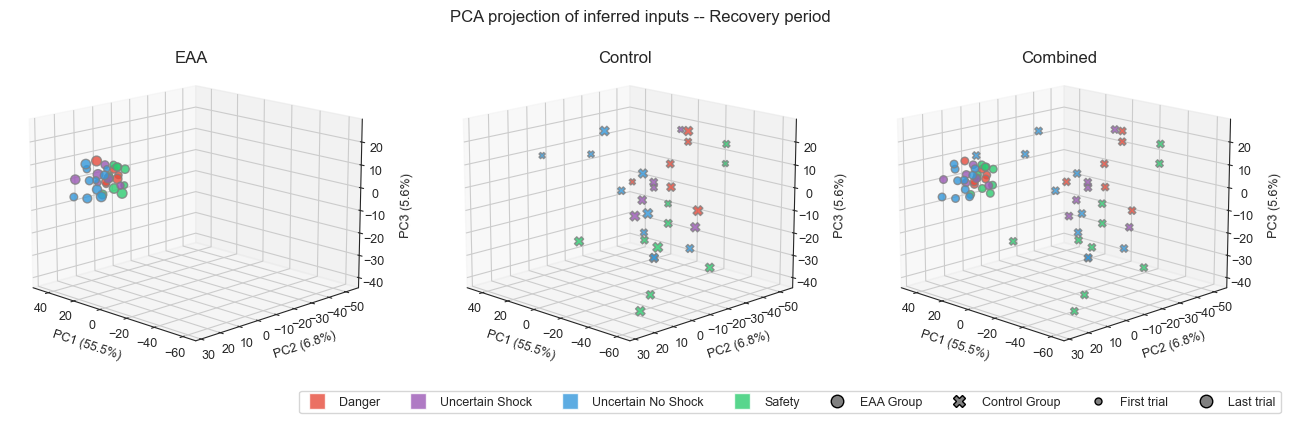

In [ ]:
plot_pca_tri_panel(inferred_inputs['EAA'][:, 170:, :], inferred_inputs['Ctr'][:, 170:, :], title='PCA projection of inferred inputs -- Recovery period', elev=15, azim=135)

# Behavioural data

In [ ]:
pokes_EAA = np.load('avg_poke_list_EAA.npy')[:, 30:]
pokes_Ctr = np.load('avg_poke_list_Ctr.npy')[:, 30:]
pokes_all = np.load('avg_poke_list.npy')

In [ ]:
pokes_EAA.shape, pokes_Ctr.shape

((32, 70), (32, 70))

In [ ]:
pokes = {
    'EAA': pokes_EAA,
    'Ctr': pokes_Ctr
}

In [ ]:
factors['EAA'].shape

(32, 350, 40)

/tmp/ipykernel_3926007/2886849944.py:51: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


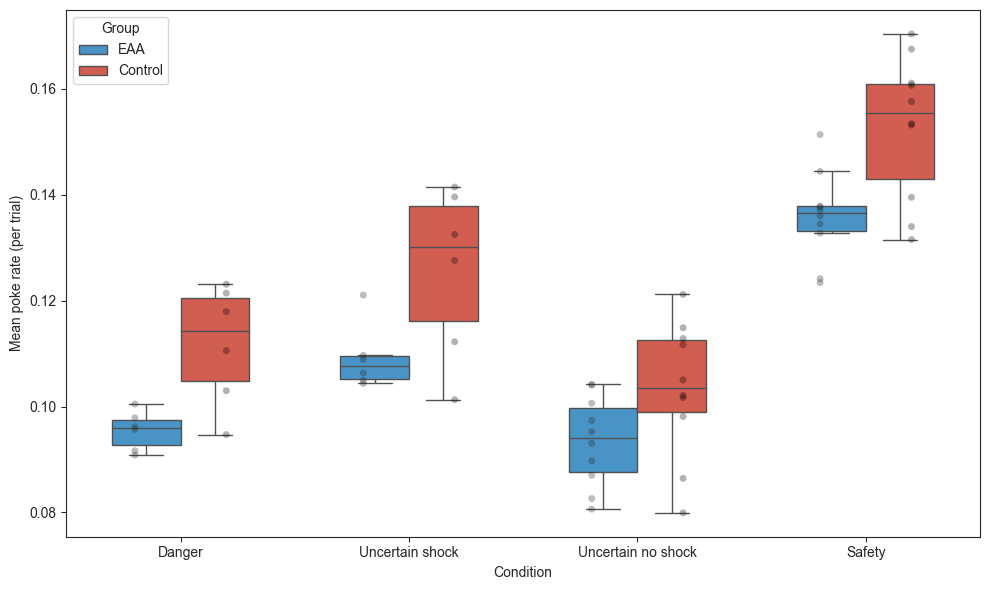

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Define the condition ranges and labels
cond_ranges = [
    (0, 6, "Danger"),
    (6, 12, "Uncertain shock"),
    (12, 22, "Uncertain no shock"),
    (22, 32, "Safety")
]

data_list = []

def process_2d_pokes(pokes_array, group_name):
    # pokes_array shape: (32, 70) -> (Trials, Time)
    for start, end, label in cond_ranges:
        # Calculate mean across time for each trial in this range
        # Result is a 1D array of trial averages (e.g., length 6 or 10)
        trial_means = pokes_array[start:end, :].mean(axis=1)
        
        for val in trial_means:
            data_list.append({
                'Condition': label,
                'Group': group_name,
                'Mean poke rate': val
            })

# Process both 2D arrays
process_2d_pokes(pokes_EAA, 'EAA')
process_2d_pokes(pokes_Ctr, 'Control')

df_compare = pd.DataFrame(data_list)

# Plotting
plt.figure(figsize=(10, 6))

# Boxplot for the distribution of trial averages
sns.boxplot(
    data=df_compare, 
    x='Condition', 
    y='Mean poke rate', 
    hue='Group', 
    palette={'EAA': '#3498db', 'Control': '#e74c3c'},
    width=0.6,
    showfliers=False
)

# Stripplot to show every single trial as a dot
sns.stripplot(
    data=df_compare, 
    x='Condition', 
    y='Mean poke rate', 
    hue='Group', 
    dodge=True, 
    color='black', 
    alpha=0.3, 
    jitter=False,
    legend=False
)

# plt.title('Trial-by-Trial Poke Rate: EAA vs Control')
plt.ylabel('Mean poke rate (per trial)')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import (
    train_test_split,
    GroupKFold,
    GridSearchCV,
)
from sklearn.ensemble import RandomForestRegressor

n_lag = 5

cond_groups = {
    "Danger": lambda x: 0 <= x < 6,
    "Uncertain shock": lambda x: 6 <= x < 12,
    "Uncertain no shock": lambda x: 12 <= x < 22,
    "Safety": lambda x: 22 <= x < 32
}

data_types = {
    "LFADS factors": factors,
    "Smoothed spikes": spikes,
}

sessions = sorted(spikes.keys())
results = []

for cond_group, include_fn in cond_groups.items():
    for sess in sessions:
        for data_type, data in data_types.items():
            
            # --- Data Preparation & Alignment ---
            num_trials = data[sess].shape[0]
            n_t_neural = data[sess].shape[1] # 350
            n_t_pokes = pokes[sess].shape[1]  # 70
            
            trial_indices = np.arange(num_trials)
            mask = np.array([include_fn(i) for i in trial_indices])
            
            # Skip if condition has no trials in this session
            if not np.any(mask): 
                continue

            # 1. Resample Pokes for this session
            pokes_orig = pokes[sess][mask] 
            n_tr_curr = pokes_orig.shape[0]
            
            pokes_resampled = np.zeros((n_tr_curr, n_t_neural))
            x_orig = np.linspace(0, 1, n_t_pokes)
            x_new = np.linspace(0, 1, n_t_neural)
            
            for i in range(n_tr_curr):
                pokes_resampled[i] = np.interp(x_new, x_orig, pokes_orig[i])

            # 2. Align Neural and Poke data (Lagging)
            # Neural (X): (Trials, 345, Feats)
            x_curr = data[sess][mask, :-n_lag, :]
            # Pokes (Y): (Trials, 345)
            y_curr = pokes_resampled[:, n_lag:]

            # --- Within-Day Train/Test Split ---
            # We split at the trial level to ensure timepoints stay grouped
            x_train, x_test, y_train, y_test = train_test_split(
                x_curr, y_curr, test_size=0.2, random_state=42
            )

            # --- Flatten for Scikit-Learn ---
            n_tr_train, n_t_train, n_feats = x_train.shape
            x_train_flat = x_train.reshape(-1, n_feats)
            y_train_flat = y_train.reshape(-1, 1)
            
            x_test_flat = x_test.reshape(-1, n_feats)
            y_test_flat = y_test.reshape(-1, 1)

            # Define groups for GroupKFold validation
            groups = np.repeat(np.arange(n_tr_train), n_t_train)
            n_unique_trials = len(np.unique(groups))

            # Skip if we don't have enough trials for cross-validation
            if n_unique_trials < 2:
                continue
            
            # --- Model Fitting ---
            n_splits = min(4, n_unique_trials) # Using 3-fold for stability with small trial counts

            model = GridSearchCV(
            Lasso(max_iter=20000),
            param_grid={"alpha": np.logspace(-6, -1, 6)},
            cv=GroupKFold(n_splits=n_splits),
            )

            # rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)

            # param_grid = {
            #     "n_estimators": [100],         # Number of trees
            #     "max_depth": [5, 10, None],    # Limit depth to prevent overfitting on small trial counts
            #     "max_features": ["sqrt"]       # Good default for high-dimensional neural data
            # }
            
            # model = GridSearchCV(
            #     rf_model,
            #     param_grid=param_grid,
            #     cv=GroupKFold(n_splits=n_splits),
            # )
            
            # --- Model Fitting ---
            # model.fit(x_train_flat, y_train_flat.ravel(), groups=groups)
            model.fit(x_train_flat, y_train_flat, groups=groups)

            # --- Trial-by-Trial Evaluation ---
            # x_test has shape (n_test_trials, n_timesteps, n_feats)
            n_test_trials = x_test.shape[0]
            
            from sklearn.metrics import r2_score

            for t_idx in range(n_test_trials):
                # 1. Get data for this single trial
                trial_x = x_test[t_idx] # (timesteps, feats)
                trial_y = y_test[t_idx] # (timesteps, 1)
                
                # 2. Predict behavior for this trial
                trial_pred = model.predict(trial_x)
                
                # 3. Calculate R2 for this specific trial
                trial_r2 = r2_score(trial_y, trial_pred)

                # 4. Save individual trial result
                results.append({
                    "group": sess,
                    "cond_group": cond_group,
                    "session": sess,
                    "data_type": data_type,
                    "trial_id": t_idx, # Track which trial this was
                    "r2_score": trial_r2,
                })

df_results = pd.DataFrame(results)
print(df_results)

   group          cond_group session        data_type  trial_id  r2_score
0    Ctr              Danger     Ctr    LFADS factors         0  0.371847
1    Ctr              Danger     Ctr    LFADS factors         1  0.587668
2    Ctr              Danger     Ctr  Smoothed spikes         0  0.500006
3    Ctr              Danger     Ctr  Smoothed spikes         1  0.425387
4    EAA              Danger     EAA    LFADS factors         0  0.745721
5    EAA              Danger     EAA    LFADS factors         1  0.772221
6    EAA              Danger     EAA  Smoothed spikes         0  0.618607
7    EAA              Danger     EAA  Smoothed spikes         1  0.677392
8    Ctr     Uncertain shock     Ctr    LFADS factors         0  0.545390
9    Ctr     Uncertain shock     Ctr    LFADS factors         1  0.472841
10   Ctr     Uncertain shock     Ctr  Smoothed spikes         0  0.510993
11   Ctr     Uncertain shock     Ctr  Smoothed spikes         1  0.415330
12   EAA     Uncertain shock     EAA  

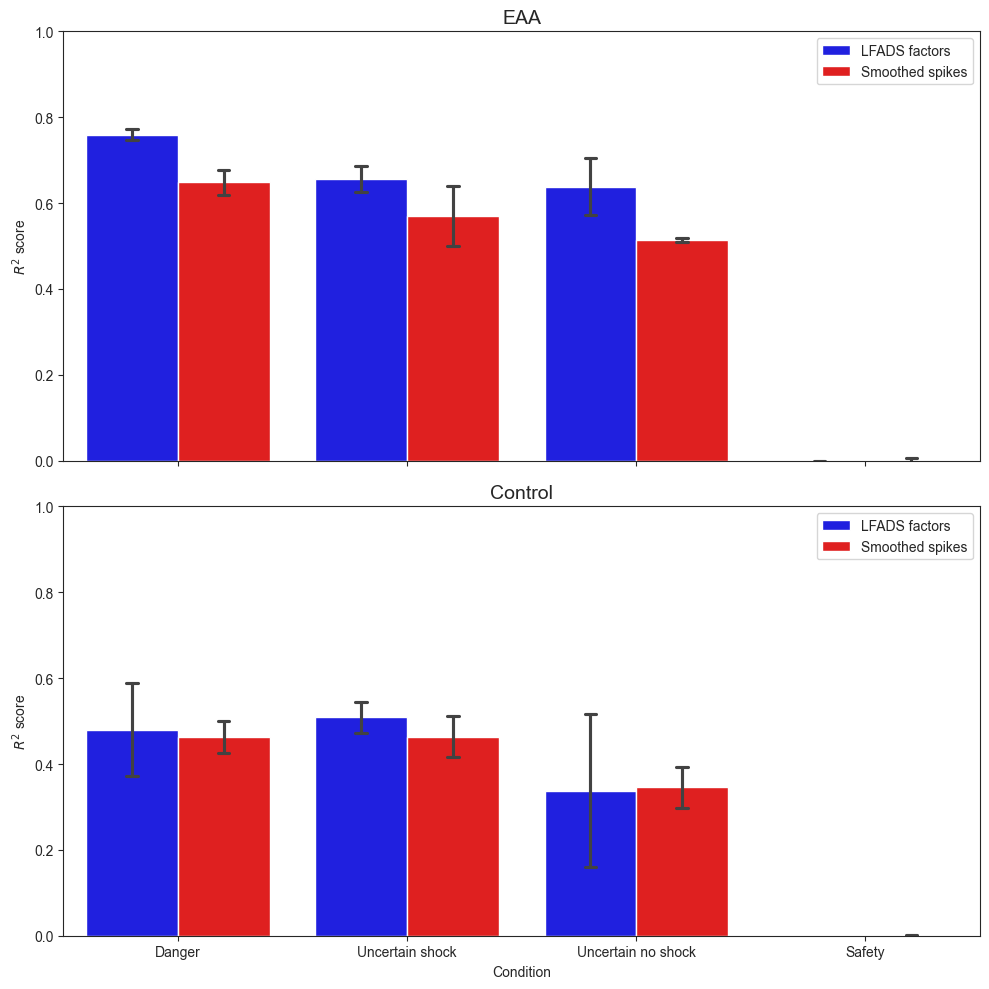

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the DataFrame
df = pd.DataFrame(results)

# Optional: If 'group' isn't in your results, add it based on session ID
df['group'] = df['session']

# 2. Set the order for the X-axis conditions
condition_order = ["Danger", "Uncertain shock", "Uncertain no shock", "Safety"]

# 3. Create the figure with two subplots (Stacked vertically)
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True, sharey=True)

groups = ["EAA", "Ctr"]
colors = ["blue", "red"]

for i, group in enumerate(groups):
    # Filter data for the specific group (EAA or Control)
    group_df = df[df['group'] == group]
    
    sns.barplot(
        data=group_df,
        x="cond_group",
        y="r2_score",
        hue="data_type",
        order=condition_order,
        palette=colors,
        ax=axes[i],
        capsize=.1,
        errorbar="se" # Adds standard error bars if you have multiple sessions per group
    )
    
    # Formatting
    axes[i].set_ylabel("$R^2$ score")
    axes[i].set_ylim(0, 1)
    axes[i].legend(loc="upper right")

axes[0].set_title("EAA",fontsize=14)
axes[1].set_title("Control",fontsize=14)

# Final Cleanup
axes[1].set_xlabel("Condition")
# plt.xticks(rotation=15)
plt.tight_layout()
plt.show()